In [27]:
import json
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bert_score import score as calc_bert_score
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [28]:
# ==============================================================
# CONFIGURAÇÕES
# ==============================================================

FILE_PATH = "rag_cli_output_mlx_DeepSeek-R1-Distill-Qwen-7B-4bit_Kwid_Nov24_50.json"
MODEL_NAMES = ["original", "shuffled"]
F1_THRESH = 0.5

SOFT_PALETTE = [
    "#34C8FE",  # blue
    "#FF99BA",  # lilac #FF99BA
    "#C0A8FF",  # pink
    "#8FD7F2",  # light blue
    "#C8C8F4",  # light lilac
    "#F5B4DE"   # light pink
]

# Ajusta o estilo do Matplotlib para um layout minimalista
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.edgecolor'] = '#000000'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#EEEEEE'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['xtick.color'] = '#000000'
plt.rcParams['ytick.color'] = '#000000'
plt.rcParams['axes.labelcolor'] = '#000000'
plt.rcParams['axes.titlecolor'] = '#000000'

plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

plt.rcParams['legend.frameon'] = False
plt.rcParams['patch.edgecolor'] = 'none'

In [29]:
# ==============================================================
# UTILITÁRIOS DE TEXTO
# ==============================================================

stemmer = RSLPStemmer()

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    return text

def simple_tokenize(text):
    if not isinstance(text, str):
        return []
    return re.findall(r"\w+", normalize_text(text))

def _to_tokens(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple)):
        return [str(t).lower() for t in x]
    if isinstance(x, str):
        return re.findall(r"\w+", normalize_text(x))
    return re.findall(r"\w+", normalize_text(str(x)))

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def safe_len_tokens_col(df, colname, fallback_text_col=None):
    def token_count(row):
        values = row.get(colname, []) if colname in row.index else []
        n = len(_to_tokens(values))
        if n == 0 and fallback_text_col and fallback_text_col in row.index:
            return len(_to_tokens(row.get(fallback_text_col, "")))
        return n

    if colname in df.columns:
        return df.apply(token_count, axis=1)
    if fallback_text_col and fallback_text_col in df.columns:
        return df[fallback_text_col].apply(lambda v: len(_to_tokens(v)))
    return pd.Series([np.nan] * len(df), index=df.index)

def jaccard_similarity(text1, text2, use_stem=False):
    tok1 = _to_tokens(text1)
    tok2 = _to_tokens(text2)

    if use_stem:
        tok1 = stem_tokens(tok1)
        tok2 = stem_tokens(tok2)

    set1 = set(tok1)
    set2 = set(tok2)

    union = set1 | set2
    inter = set1 & set2

    return len(inter) / len(union) if union else 0.0

In [30]:
# ==============================================================
# KEYWORDS DE DÚVIDA
# ==============================================================

DOUBT_KEYWORDS_MULTILINGUAL = [
    "not sure", "doesn't mention", "cannot find", "no information",
    "doesn't directly", "not specifically", "i don't see",
    "nao tenho certeza", "nao sei", "nao encontrei",
    "nao foi possivel encontrar", "nao ha informacao",
    "sem informacao", "o texto nao menciona", "o contexto nao menciona",
    "o manual nao menciona", "nao esta claro", "nao esta especificado",
    "nao menciona diretamente", "nao consta"
]
DOUBT_KEYWORDS_MULTILINGUAL = [normalize_text(k) for k in DOUBT_KEYWORDS_MULTILINGUAL]

def count_doubt_markers(text):
    if not isinstance(text, str):
        return 0
    text_norm = normalize_text(text)
    return sum(1 for expr in DOUBT_KEYWORDS_MULTILINGUAL if expr in text_norm)

# ==============================================================
# CARGA DO JSON
# ==============================================================

def load_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)


In [31]:
# ==============================================================
# CONSTRUÇÃO DO DATAFRAME
# ==============================================================

def extract_retrieved_context(retrieved_chunks):
    if not isinstance(retrieved_chunks, (list, tuple)):
        return ""
    texts = []
    for c in retrieved_chunks:
        if isinstance(c, dict):
            texts.append(c.get("text", ""))
        else:
            texts.append(str(c))
    return " ".join(texts)

def build_records(data, model_names=MODEL_NAMES):
    records = []

    for item in data:
        question = item.get("question", "")
        gabarito = item.get("original_answer", "")

        for model_name in model_names:
            model_data = item.get(model_name, {}) or {}
            retrieved_chunks = model_data.get("retrieved_chunks", [])

            records.append({
                "question": question,
                "gabarito": gabarito,
                "model": model_name,

                # textos
                "reasoning_text": model_data.get("reasoning_text", ""),
                "answer_text": model_data.get("answer_text", ""),
                "raw_output": model_data.get("raw_output", ""),
                "clean_raw_output": model_data.get("clean_raw_output", ""),
                "formatted_prompt": model_data.get("formatted_prompt", ""),

                # tokens / ids
                "reasoning_tokens": model_data.get("reasoning_tokens", []),
                "answer_tokens": model_data.get("answer_tokens", []),
                "reasoning_ids": model_data.get("reasoning_ids", []),
                "answer_ids": model_data.get("answer_ids", []),
                "generated_ids": model_data.get("generated_ids", []),
                "input_ids": model_data.get("input_ids", []),

                # recuperação
                "retrieved_chunks": retrieved_chunks,
                "retrieved_context": extract_retrieved_context(retrieved_chunks),

                # contagens do modelo
                "input_token_count": model_data.get("input_token_count", np.nan),
                "output_token_count": model_data.get("output_token_count", np.nan),

                # tags de reasoning
                "reasoning_tag_name": model_data.get("reasoning_tag_name", ""),
                "reasoning_start_tag": model_data.get("reasoning_start_tag", ""),
                "reasoning_end_tag": model_data.get("reasoning_end_tag", ""),
                "reasoning_start_tag_ids": model_data.get("reasoning_start_tag_ids", []),
                "reasoning_end_tag_ids": model_data.get("reasoning_end_tag_ids", []),
                "reasoning_start_tag_tokens": model_data.get("reasoning_start_tag_tokens", []),
                "reasoning_end_tag_tokens": model_data.get("reasoning_end_tag_tokens", []),
                "reasoning_start_tag_start_idx": model_data.get("reasoning_start_tag_start_idx", np.nan),
                "reasoning_start_tag_end_idx": model_data.get("reasoning_start_tag_end_idx", np.nan),
                "reasoning_end_tag_start_idx": model_data.get("reasoning_end_tag_start_idx", np.nan),
                "reasoning_end_tag_end_idx": model_data.get("reasoning_end_tag_end_idx", np.nan),

                # tokenizer
                "tokenizer_info": model_data.get("tokenizer_info", {}),
            })

    return pd.DataFrame(records)

In [32]:
# ==============================================================
# MÉTRICAS BASE
# ==============================================================

def add_basic_features(df):
    df = df.copy()

    # contagem robusta de tokens
    df["reasoning_tok_count"] = safe_len_tokens_col(df, "reasoning_tokens", "reasoning_text")
    df["answer_tok_count"] = safe_len_tokens_col(df, "answer_tokens", "answer_text")

    # comprimentos em caracteres
    df["reasoning_len_chars"] = df["reasoning_text"].fillna("").str.len()
    df["answer_len_chars"] = df["answer_text"].fillna("").str.len()

    # razão reasoning / resposta
    df["reasoning_ratio"] = df["reasoning_tok_count"] / (df["answer_tok_count"] + 1)

    # dúvida no raciocínio
    df["doubt_count"] = df["reasoning_text"].apply(count_doubt_markers)

    # sobreposição lexical entre contexto recuperado e CoT
    # OBS: não é copy-paste literal; é overlap lexical por conjunto
    df["retrieval_reasoning_lexical_overlap"] = df.apply(
        lambda row: jaccard_similarity(
            row["retrieved_context"],
            row["reasoning_text"],
            use_stem=False
        ),
        axis=1
    )

    # overlap entre reasoning e resposta
    df["reasoning_answer_overlap"] = df.apply(
        lambda row: jaccard_similarity(
            row["reasoning_text"],
            row["answer_text"],
            use_stem=False
        ),
        axis=1
    )

    # rótulo legível
    df["model_label"] = df["model"].map({
        "original": "Original",
        "shuffled": "Shuffled"
    }).fillna(df["model"])

    return df


In [33]:
# ==============================================================
# MÉTRICAS DE COBERTURA DO CoT NO CONTEXTO
# ==============================================================

def overlap_metrics(row):
    r_tok = set(stem_tokens(_to_tokens(row.get("reasoning_text", ""))))

    if not r_tok:
        return pd.Series({
            "cot_cov_overall": 0.0,
            "cot_novelty": 1.0,
            "cot_retrieval_jaccard": 0.0,
            "cot_chunk_max_cov": np.nan,
            "cot_chunk_argmax": np.nan,
            "cot_chunk_entropy": 0.0,
            "cot_chunks_used": 0,
        })

    retrieval_text = row.get("retrieved_context", "")
    ret_tok = set(stem_tokens(_to_tokens(retrieval_text)))

    inter = r_tok & ret_tok
    union = r_tok | ret_tok

    cot_cov_overall = len(inter) / len(r_tok) if r_tok else 0.0
    cot_novelty = 1.0 - cot_cov_overall
    cot_retrieval_jaccard = len(inter) / len(union) if union else 0.0

    chunks = row.get("retrieved_chunks", [])
    if not isinstance(chunks, (list, tuple)) or len(chunks) == 0:
        return pd.Series({
            "cot_cov_overall": cot_cov_overall,
            "cot_novelty": cot_novelty,
            "cot_retrieval_jaccard": cot_retrieval_jaccard,
            "cot_chunk_max_cov": np.nan,
            "cot_chunk_argmax": np.nan,
            "cot_chunk_entropy": 0.0,
            "cot_chunks_used": 0,
        })

    per_chunk_cov = []
    for c in chunks:
        chunk_text = c.get("text", "") if isinstance(c, dict) else str(c)
        c_tok = set(stem_tokens(_to_tokens(chunk_text)))
        cov = len(r_tok & c_tok) / len(r_tok) if r_tok else 0.0
        per_chunk_cov.append(cov)

    per_chunk_cov = np.array(per_chunk_cov, dtype=float)

    if len(per_chunk_cov) == 0:
        max_cov = np.nan
        argmax = np.nan
        entropy = 0.0
        chunks_used = 0
    else:
        max_cov = float(np.nanmax(per_chunk_cov))
        argmax = int(np.nanargmax(per_chunk_cov))

        weights = per_chunk_cov[per_chunk_cov > 0]
        if weights.size == 0:
            entropy = 0.0
            chunks_used = 0
        else:
            p = weights / weights.sum()
            entropy = -float(np.sum(p * np.log(p + 1e-12)))
            chunks_used = int((per_chunk_cov > 0).sum())

    return pd.Series({
        "cot_cov_overall": cot_cov_overall,
        "cot_novelty": cot_novelty,
        "cot_retrieval_jaccard": cot_retrieval_jaccard,
        "cot_chunk_max_cov": max_cov,
        "cot_chunk_argmax": argmax,
        "cot_chunk_entropy": entropy,
        "cot_chunks_used": chunks_used,
    })

def add_cot_overlap_features(df):
    df = df.copy()
    cot_metrics = df.apply(overlap_metrics, axis=1)
    return pd.concat([df, cot_metrics], axis=1)

In [34]:
# ==============================================================
# BERTScore
# ==============================================================

def add_bertscore_vs_gabarito(df):
    df = df.copy()

    print("Calculando BERTScore da resposta final vs gabarito...")
    _, _, f1_gabarito = calc_bert_score(
        df["answer_text"].fillna("").tolist(),
        df["gabarito"].fillna("").tolist(),
        model_type="bert-base-multilingual-cased",
        num_layers=12,
        verbose=True
    )

    df["f1_vs_gabarito"] = f1_gabarito.cpu().numpy()
    df["is_success"] = (df["f1_vs_gabarito"] >= F1_THRESH).astype(int)

    return df


In [35]:
# ==============================================================
# SUMÁRIOS
# ==============================================================

def build_model_summary(df):
    summary = (
        df.groupby("model")
          .agg(
              n=("f1_vs_gabarito", "size"),
              f1_mean=("f1_vs_gabarito", "mean"),
              f1_median=("f1_vs_gabarito", "median"),
              success_rate=("is_success", "mean"),
              doubt_mean=("doubt_count", "mean"),
              reasoning_tok_mean=("reasoning_tok_count", "mean"),
              answer_tok_mean=("answer_tok_count", "mean"),
              reasoning_ratio_mean=("reasoning_ratio", "mean"),
              in_tok_mean=("input_token_count", "mean"),
              out_tok_mean=("output_token_count", "mean"),
              retrieval_reasoning_overlap_mean=("retrieval_reasoning_lexical_overlap", "mean"),
              reasoning_answer_overlap_mean=("reasoning_answer_overlap", "mean"),
              cot_cov_mean=("cot_cov_overall", "mean"),
              cot_novelty_mean=("cot_novelty", "mean"),
              cot_chunk_max_cov_mean=("cot_chunk_max_cov", "mean"),
              cot_chunk_entropy_mean=("cot_chunk_entropy", "mean"),
              cot_chunks_used_mean=("cot_chunks_used", "mean"),
          )
          .reset_index()
          .sort_values("model")
    )
    return summary

def build_success_summary(df):
    return (
        df.groupby(["model", "is_success"])
          .agg(
              n=("question", "size"),
              f1_mean=("f1_vs_gabarito", "mean"),
              doubt_mean=("doubt_count", "mean"),
              retrieval_reasoning_overlap_mean=("retrieval_reasoning_lexical_overlap", "mean"),
              reasoning_answer_overlap_mean=("reasoning_answer_overlap", "mean"),
              cot_cov_mean=("cot_cov_overall", "mean"),
              cot_novelty_mean=("cot_novelty", "mean"),
              cot_chunk_entropy_mean=("cot_chunk_entropy", "mean"),
              cot_chunks_used_mean=("cot_chunks_used", "mean"),
          )
          .reset_index()
          .sort_values(["model", "is_success"])
    )

def build_model_correlations(df):
    corr_cols = [
        "f1_vs_gabarito",
        "doubt_count",
        "reasoning_tok_count",
        "answer_tok_count",
        "reasoning_ratio",
        "retrieval_reasoning_lexical_overlap",
        "reasoning_answer_overlap",
        "cot_cov_overall",
        "cot_novelty",
        "cot_retrieval_jaccard",
        "cot_chunk_max_cov",
        "cot_chunk_entropy",
        "cot_chunks_used",
    ]

    corr_tables = {}
    for model in df["model"].dropna().unique():
        corr_tables[model] = df.loc[df["model"] == model, corr_cols].corr()

    return corr_tables

In [36]:
# ==============================================================
# SUPORTE SENTENÇA -> CHUNK
# ==============================================================

def split_sentences(text):
    text = "" if text is None else str(text)
    sents = re.split(r'(?<=[\.\!\?])\s+', text.strip())
    return [s.strip() for s in sents if s.strip()]

def sentence_support_metrics(row, sim_thresh=0.20, max_k=5):
    chunks = row.get("retrieved_chunks", [])
    if not isinstance(chunks, (list, tuple)):
        chunks = []
    chunks = chunks[:max_k]

    chunk_texts = []
    for c in chunks:
        if isinstance(c, dict):
            chunk_texts.append(c.get("text", ""))
        else:
            chunk_texts.append(str(c))

    sents = split_sentences(row.get("reasoning_text", ""))

    if len(sents) == 0 or len(chunk_texts) == 0:
        return pd.Series({
            "sent_support_rate": np.nan,
            "sent_low_support_rate": np.nan,
            "sent_mean_max_sim": np.nan,
            "sent_median_max_sim": np.nan,
            "sent_argmax_chunk_mode": np.nan
        })

    corpus = chunk_texts + sents
    vec = TfidfVectorizer(min_df=1, ngram_range=(1, 2))
    X = vec.fit_transform(corpus)

    X_chunks = X[:len(chunk_texts)]
    X_sents = X[len(chunk_texts):]

    sims = cosine_similarity(X_sents, X_chunks)
    max_sim = sims.max(axis=1)
    argmax = sims.argmax(axis=1)

    support = (max_sim >= sim_thresh).astype(int)
    mode_chunk = int(pd.Series(argmax).mode().iloc[0]) if len(argmax) else np.nan

    return pd.Series({
        "sent_support_rate": float(np.mean(support)),
        "sent_low_support_rate": float(np.mean(max_sim < (sim_thresh / 2))),
        "sent_mean_max_sim": float(np.mean(max_sim)),
        "sent_median_max_sim": float(np.median(max_sim)),
        "sent_argmax_chunk_mode": mode_chunk
    })

def add_sentence_support_features(df, sim_thresh=0.20, max_k=8):
    df = df.copy()
    sent_metrics = df.apply(
        lambda row: sentence_support_metrics(row, sim_thresh=sim_thresh, max_k=max_k),
        axis=1
    )
    return pd.concat([df, sent_metrics], axis=1)

In [37]:
# ==============================================================
# ANÁLISE PAREADA ORIGINAL VS SHUFFLED
# ==============================================================

def build_paired_delta_table(df):
    pair_key = "question"

    metrics = [
        "f1_vs_gabarito",
        "cot_cov_overall",
        "cot_novelty",
        "cot_chunk_entropy",
        "retrieval_reasoning_lexical_overlap",
        "reasoning_answer_overlap",
        "doubt_count",
        "sent_support_rate"
    ]
    metrics = [c for c in metrics if c in df.columns]

    wide = df.pivot_table(
        index=pair_key,
        columns="model",
        values=metrics,
        aggfunc="mean"
    )

    needed_cols = ["original", "shuffled"]
    if not all(m in wide.columns.get_level_values(1) for m in needed_cols):
        raise ValueError("As colunas 'original' e 'shuffled' precisam estar em df['model'].")

    delta = {}
    for m in metrics:
        delta[f"{m}_delta"] = wide[(m, "shuffled")] - wide[(m, "original")]

    delta = pd.DataFrame(delta)
    return delta

In [38]:
# ==============================================================
# COBERTURA POR CHUNK
# ==============================================================

def per_chunk_cov_vector(row, max_k=5):
    r_tok = set(stem_tokens(_to_tokens(row.get("reasoning_text", ""))))
    chunks = row.get("retrieved_chunks", [])

    if not isinstance(chunks, (list, tuple)):
        chunks = []

    covs = []
    for i in range(max_k):
        if i < len(chunks):
            c = chunks[i]
            chunk_text = c.get("text", "") if isinstance(c, dict) else str(c)
            c_tok = set(stem_tokens(_to_tokens(chunk_text)))
            cov = len(r_tok & c_tok) / len(r_tok) if len(r_tok) else 0.0
            covs.append(cov)
        else:
            covs.append(np.nan)

    return pd.Series(covs, index=[f"chunk_{i+1}_cov" for i in range(max_k)])

In [39]:
# ==============================================================
# VISUALIZAÇÕES
# ==============================================================

def plot_cot_coverage_by_success(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.boxplot(
        data=df,
        x="is_success",
        y="cot_cov_overall",
        hue="model",
        palette=SOFT_PALETTE[:2],
        ax=ax
    )

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    # ax.set_title("Cobertura da CoT por sucesso da resposta", pad=15)
    ax.set_xlabel("Resposta correta (0 = não, 1 = sim)")
    ax.set_ylabel("Cobertura da CoT no contexto")

    ax.legend(title="Configuração", frameon=False)
    plt.tight_layout()
    plt.savefig("cot_boxplot_model2.pdf", bbox_inches="tight")


In [40]:
# ==============================================================
# PIPELINE PRINCIPAL
# ==============================================================

data = load_json(FILE_PATH)

df = build_records(data)
df = add_basic_features(df)
df = add_cot_overlap_features(df)
df = add_bertscore_vs_gabarito(df)
df = add_sentence_support_features(df, sim_thresh=0.20, max_k=8)

Calculando BERTScore da resposta final vs gabarito...
calculating scores...
computing bert embedding.


  0%|          | 0/3 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 3.07 seconds, 32.57 sentences/sec


In [41]:
# ==============================================================
# TABELAS PRINCIPAIS
# ==============================================================

model_summary = build_model_summary(df)
success_summary = build_success_summary(df)
model_correlations = build_model_correlations(df)

print("\n=== RESUMO POR MODELO ===")
display(model_summary)

print("\n=== RESUMO POR MODELO E SUCESSO ===")
display(success_summary)

print("\n=== CORRELAÇÕES: ORIGINAL ===")
if "original" in model_correlations:
    display(model_correlations["original"])

print("\n=== CORRELAÇÕES: SHUFFLED ===")
if "shuffled" in model_correlations:
    display(model_correlations["shuffled"])


=== RESUMO POR MODELO ===


,model,n,f1_mean,f1_median,success_rate,doubt_mean,reasoning_tok_mean,answer_tok_mean,reasoning_ratio_mean,in_tok_mean,out_tok_mean,retrieval_reasoning_overlap_mean,reasoning_answer_overlap_mean,cot_cov_mean,cot_novelty_mean,cot_chunk_max_cov_mean,cot_chunk_entropy_mean,cot_chunks_used_mean
0,original,50,0.616842,0.630164,0.84,0.08,161.16,27.34,7.749730,1771.42,298.56,0.106019,0.209468,0.527217,0.472783,0.356298,2.053318,8.0
1,shuffled,50,0.638628,0.641463,0.86,0.10,170.76,27.26,7.860759,1771.42,318.62,0.118972,0.214744,0.562431,0.437569,0.370154,2.054250,8.0



=== RESUMO POR MODELO E SUCESSO ===


,model,is_success,n,f1_mean,doubt_mean,retrieval_reasoning_overlap_mean,reasoning_answer_overlap_mean,cot_cov_mean,cot_novelty_mean,cot_chunk_entropy_mean,cot_chunks_used_mean
0,original,0,8,0.436726,0.500000,0.090094,0.122463,0.462035,0.537965,2.060590,8.0
1,original,1,42,0.651149,0.000000,0.109053,0.226041,0.539633,0.460367,2.051933,8.0
2,shuffled,0,7,0.459447,0.428571,0.109126,0.085953,0.473761,0.526239,2.048204,8.0
3,shuffled,1,43,0.667797,0.046512,0.120575,0.235710,0.576865,0.423135,2.055235,8.0



=== CORRELAÇÕES: ORIGINAL ===


,f1_vs_gabarito,doubt_count,reasoning_tok_count,answer_tok_count,reasoning_ratio,retrieval_reasoning_lexical_overlap,reasoning_answer_overlap,cot_cov_overall,cot_novelty,cot_retrieval_jaccard,cot_chunk_max_cov,cot_chunk_entropy,cot_chunks_used
f1_vs_gabarito,1.000000,-0.387038,-0.385314,0.010712,-0.493003,-0.020941,0.283892,0.123293,-0.123293,-0.027301,0.292492,-0.235538,NaN
doubt_count,-0.387038,1.000000,0.210845,-0.289121,0.681394,-0.340847,-0.424722,-0.459657,0.459657,-0.351550,-0.417997,-0.024478,NaN
reasoning_tok_count,-0.385314,0.210845,1.000000,0.340449,0.347267,0.195633,-0.336621,-0.264268,0.264268,0.206269,-0.599770,0.176974,NaN
answer_tok_count,0.010712,-0.289121,0.340449,1.000000,-0.545455,0.284740,0.342570,0.105813,-0.105813,0.296134,-0.118095,0.117932,NaN
reasoning_ratio,-0.493003,0.681394,0.347267,-0.545455,1.000000,-0.237664,-0.645799,-0.400104,0.400104,-0.233483,-0.457881,0.058923,NaN
retrieval_reasoning_lexical_overlap,-0.020941,-0.340847,0.195633,0.284740,-0.237664,1.000000,0.483358,0.797501,-0.797501,0.984994,0.499019,0.387349,NaN
reasoning_answer_overlap,0.283892,-0.424722,-0.336621,0.342570,-0.645799,0.483358,1.000000,0.700424,-0.700424,0.474228,0.738175,0.279330,NaN
cot_cov_overall,0.123293,-0.459657,-0.264268,0.105813,-0.400104,0.797501,0.700424,1.000000,-1.000000,0.806083,0.854195,0.405789,NaN
cot_novelty,-0.123293,0.459657,0.264268,-0.105813,0.400104,-0.797501,-0.700424,-1.000000,1.000000,-0.806083,-0.854195,-0.405789,NaN
cot_retrieval_jaccard,-0.027301,-0.351550,0.206269,0.296134,-0.233483,0.984994,0.474228,0.806083,-0.806083,1.000000,0.485214,0.417477,NaN



=== CORRELAÇÕES: SHUFFLED ===


,f1_vs_gabarito,doubt_count,reasoning_tok_count,answer_tok_count,reasoning_ratio,retrieval_reasoning_lexical_overlap,reasoning_answer_overlap,cot_cov_overall,cot_novelty,cot_retrieval_jaccard,cot_chunk_max_cov,cot_chunk_entropy,cot_chunks_used
f1_vs_gabarito,1.000000,-0.317125,-0.509480,-0.014923,-0.480939,-0.085679,0.366346,0.161237,-0.161237,-0.095456,0.349322,0.029650,NaN
doubt_count,-0.317125,1.000000,0.450966,-0.178367,0.700692,-0.200240,-0.496039,-0.384869,0.384869,-0.198767,-0.387906,0.026849,NaN
reasoning_tok_count,-0.509480,0.450966,1.000000,0.311457,0.440636,-0.063752,-0.663165,-0.499392,0.499392,-0.030895,-0.722293,-0.196604,NaN
answer_tok_count,-0.014923,-0.178367,0.311457,1.000000,-0.529577,-0.186806,0.172957,-0.340805,0.340805,-0.154436,-0.319166,-0.311232,NaN
reasoning_ratio,-0.480939,0.700692,0.440636,-0.529577,1.000000,0.034508,-0.629688,-0.136772,0.136772,0.016005,-0.292834,0.109013,NaN
retrieval_reasoning_lexical_overlap,-0.085679,-0.200240,-0.063752,-0.186806,0.034508,1.000000,0.253983,0.776809,-0.776809,0.978743,0.494372,0.556047,NaN
reasoning_answer_overlap,0.366346,-0.496039,-0.663165,0.172957,-0.629688,0.253983,1.000000,0.539258,-0.539258,0.262061,0.668822,0.239768,NaN
cot_cov_overall,0.161237,-0.384869,-0.499392,-0.340805,-0.136772,0.776809,0.539258,1.000000,-1.000000,0.782621,0.835094,0.518175,NaN
cot_novelty,-0.161237,0.384869,0.499392,0.340805,0.136772,-0.776809,-0.539258,-1.000000,1.000000,-0.782621,-0.835094,-0.518175,NaN
cot_retrieval_jaccard,-0.095456,-0.198767,-0.030895,-0.154436,0.016005,0.978743,0.262061,0.782621,-0.782621,1.000000,0.494048,0.522856,NaN


In [42]:
df.groupby("model")["cot_chunks_used"].value_counts(dropna=False)

model     cot_chunks_used
original  8.0                50
shuffled  8.0                50
Name: count, dtype: int64

In [43]:
# ==============================================================
# COMPARAÇÃO GLOBAL SUCCESS VS FAIL
# ==============================================================

global_success_fail = (
    df.groupby("is_success")[[
        "cot_cov_overall",
        "cot_novelty",
        "cot_chunk_entropy",
        "cot_chunks_used",
        "retrieval_reasoning_lexical_overlap",
        "doubt_count"
    ]]
    .mean()
    .reset_index()
)

print("\n=== MÉDIAS GLOBAIS: SUCCESS VS FAIL ===")
display(global_success_fail)


=== MÉDIAS GLOBAIS: SUCCESS VS FAIL ===


,is_success,cot_cov_overall,cot_novelty,cot_chunk_entropy,cot_chunks_used,retrieval_reasoning_lexical_overlap,doubt_count
0,0,0.467507,0.532493,2.054810,8.0,0.098976,0.466667
1,1,0.558468,0.441532,2.053603,8.0,0.114882,0.023529


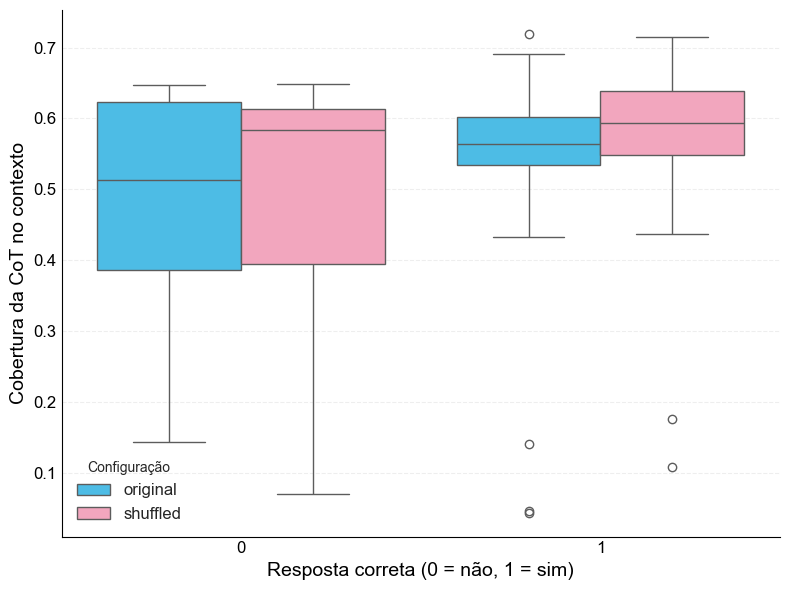

In [44]:
# ==============================================================
# VISUALIZAÇÃO
# ==============================================================

plot_cot_coverage_by_success(df)

In [45]:
def plot_sentence_support_by_success(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.boxplot(
        data=df,
        x="is_success",
        y="sent_support_rate",
        hue="model",
        palette=SOFT_PALETTE[:2],
        ax=ax
    )

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel("Resposta correta (0 = não, 1 = sim)")
    ax.set_ylabel("Taxa de sentenças suportadas")
    ax.legend(title="Configuração", frameon=False)

    plt.tight_layout()
    plt.savefig("cot_success_model2.pdf", bbox_inches="tight")

In [46]:
def plot_delta_cot_vs_delta_f1(delta_df):
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.scatterplot(
        data=delta_df,
        x="cot_cov_overall_delta",
        y="f1_vs_gabarito_delta",
        s=120,
        alpha=0.8,
        edgecolor="none",
        ax=ax
    )

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel(r"$\Delta$ Cobertura da CoT")
    ax.set_ylabel(r"$\Delta$ F1")
    # ax.set_title("Variação da cobertura da CoT vs variação do F1", pad=15)

    plt.tight_layout()
    plt.savefig("cot_delta_model2.pdf", bbox_inches="tight")

In [47]:
def plot_chunk_coverage_heatmap(df, max_k=8):
    chunk_cov = df.apply(lambda row: per_chunk_cov_vector(row, max_k=max_k), axis=1)
    df_cov = pd.concat([df[["model"]], chunk_cov], axis=1)

    pivot = df_cov.groupby("model")[[f"chunk_{i+1}_cov" for i in range(max_k)]].mean()

    fig, ax = plt.subplots(figsize=(8, 3.8))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap = sns.light_palette(SOFT_PALETTE[0], as_cmap=True),
        cbar=True,
        ax=ax
    )

    ax.set_xlabel("Posição do chunk recuperado")
    ax.set_ylabel("Configuração")

    plt.tight_layout()
    plt.savefig("cot_heatmap_model2.pdf", bbox_inches="tight")

In [48]:
delta_df = build_paired_delta_table(df)

print("\n=== DELTAS (SHUFFLED - ORIGINAL) ===")
display(delta_df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]])

if "f1_vs_gabarito_delta" in delta_df.columns:
    print("\n=== CORRELAÇÃO DOS DELTAS COM ΔF1 ===")
    display(
        delta_df.corr(numeric_only=True)[["f1_vs_gabarito_delta"]]
        .sort_values("f1_vs_gabarito_delta", ascending=False)
    )

print("\n=== SUPORTE DE SENTENÇAS POR MODELO E SUCESSO ===")
display(
    df.groupby(["model", "is_success"])
      .agg(
          n=("question", "size"),
          f1_mean=("f1_vs_gabarito", "mean"),
          sent_support_rate_mean=("sent_support_rate", "mean"),
          sent_low_support_rate_mean=("sent_low_support_rate", "mean"),
          sent_mean_max_sim_mean=("sent_mean_max_sim", "mean")
      )
      .reset_index()
)


=== DELTAS (SHUFFLED - ORIGINAL) ===


,mean,std,min,25%,50%,75%,max
f1_vs_gabarito_delta,0.021786,0.078253,-0.139981,-0.007243,0.004681,0.038145,0.418227
cot_cov_overall_delta,0.035213,0.164315,-0.436244,-0.028692,0.031651,0.074337,0.618855
cot_novelty_delta,-0.035213,0.164315,-0.618855,-0.074337,-0.031651,0.028692,0.436244
cot_chunk_entropy_delta,0.000933,0.024533,-0.105741,-0.006026,0.002278,0.007756,0.112301
retrieval_reasoning_lexical_overlap_delta,0.012953,0.045895,-0.093299,-0.011503,0.012499,0.033577,0.172439
reasoning_answer_overlap_delta,0.005276,0.099324,-0.256398,-0.035982,-0.000138,0.056338,0.257676
doubt_count_delta,0.020000,0.377424,-1.000000,0.000000,0.000000,0.000000,1.000000
sent_support_rate_delta,0.032769,0.166065,-0.444444,-0.041351,0.051632,0.146291,0.307692



=== CORRELAÇÃO DOS DELTAS COM ΔF1 ===


,f1_vs_gabarito_delta
f1_vs_gabarito_delta,1.000000
reasoning_answer_overlap_delta,0.322628
cot_cov_overall_delta,0.279401
sent_support_rate_delta,0.178518
retrieval_reasoning_lexical_overlap_delta,0.121644
cot_chunk_entropy_delta,-0.012366
cot_novelty_delta,-0.279401
doubt_count_delta,-0.295864



=== SUPORTE DE SENTENÇAS POR MODELO E SUCESSO ===


,model,is_success,n,f1_mean,sent_support_rate_mean,sent_low_support_rate_mean,sent_mean_max_sim_mean
0,original,0,8,0.436726,0.149554,0.636905,0.096864
1,original,1,42,0.651149,0.174844,0.456350,0.124048
2,shuffled,0,7,0.459447,0.171516,0.547028,0.099707
3,shuffled,1,43,0.667797,0.208784,0.418528,0.131983


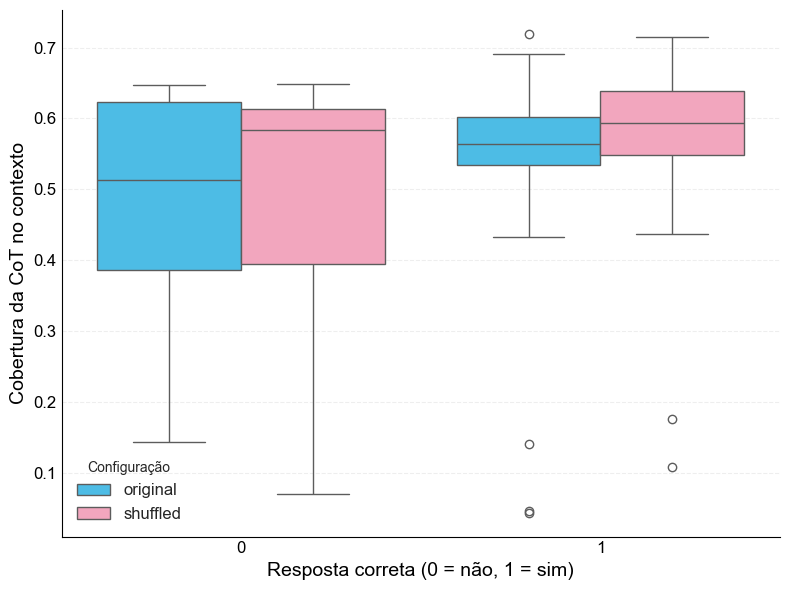

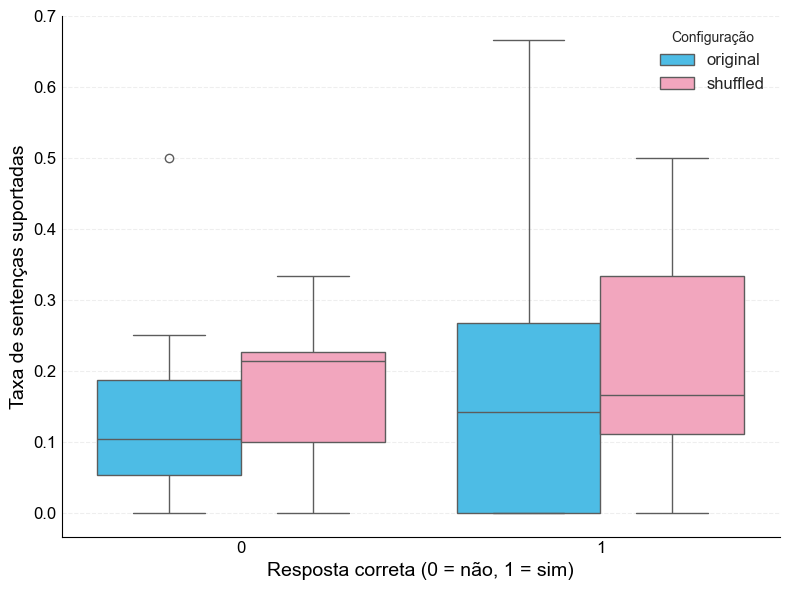

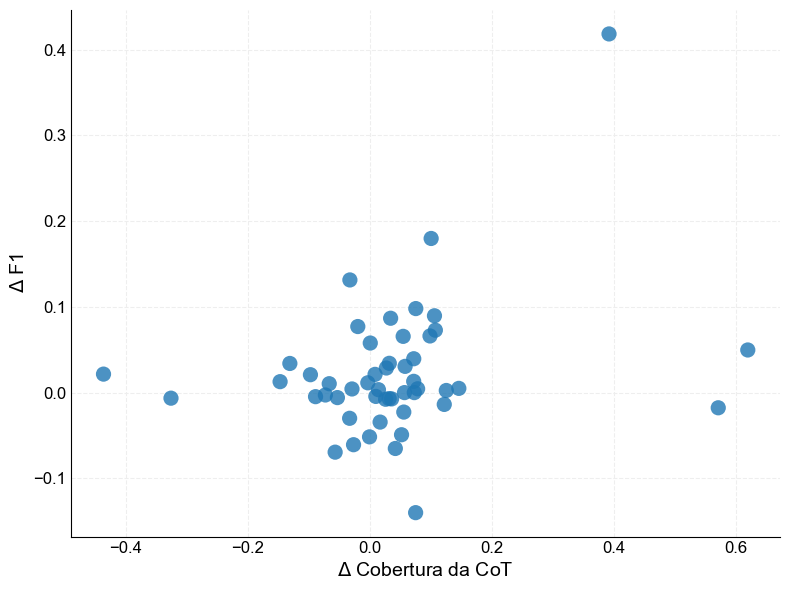

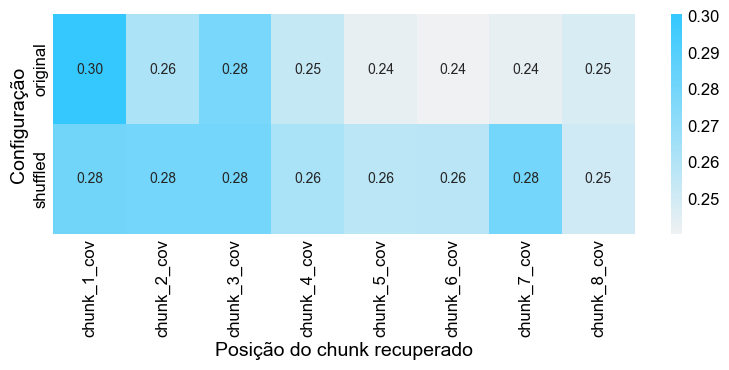

In [49]:
plot_cot_coverage_by_success(df)
plot_sentence_support_by_success(df)
plot_delta_cot_vs_delta_f1(delta_df)
plot_chunk_coverage_heatmap(df, max_k=8)